# Motor de Ajuste ao Risco (AR) — Previdência Multi-Produto | IFRS 17

**v3 do repositório de portfólio `IFRS17_Risk`** — evolução de:
`v1 (ifrs17-risk-adjustment, genérico)` → `v2 (credit-risk-ecl-engine, pivô para crédito)` → **`v3 (este projeto)`**

## O que este notebook é

Implementação de ponta a ponta da metodologia atuarial de Ajuste ao Risco (AR) sob **IFRS 17**
para produtos de **Previdência Complementar** e **Benefícios de Risco** (Peculio, Pensão por
Morte, Renda por Invalidez, Pensão ao Menor, Longevidade), consolidada em
`itau/METODOLOGIA_MESTRE.md` a partir de ~4 meses de trabalho real em uma instituição financeira.

**Dados: 100% sintéticos.** Nenhum número, volume ou resultado de nenhuma carteira real é usado.
O portfólio é gerado por simulação (idade, sexo, produto, capital segurado) e os sinistros são
sorteados a partir das próprias tábuas biométricas paramétricas do projeto — o que torna o
dataset internamente **auditável**: o A/E agregado deve ficar próximo de 100% quando calculado
contra a mesma tábua usada para gerá-lo (verificado explicitamente na seção 2 abaixo).

## Metodologia implementada (resumo)

```
Base de Expostos + Base de Sinistros (sintéticas)
        │
        ▼  conciliação por célula (idade x sexo x produto x mês)
Série histórica de sinistralidade / A/E ratio
        │
        ▼  credibility testing (Bühlmann) + seleção de distribuição (AIC/BIC/KS)
Simulação de Monte Carlo (Gamma, N cenários, semente fixa)
        │
        ▼  percentil-alvo (P75/P80/P90) / mediana
Fator de stress
        │
        ▼  aplicado à tábua biométrica
QX_stress = fator x QX_base  →  BEL_stress = VPL(QX_stress)
        │
        ▼
AR = BEL_stress − BEL_base  (por componente/"caixinha")
        │
        ▼  soma com benefício de diversificação
AR total  →  impacto no CSM (CSM cai R$1 para cada R$1 de AR)
```

Ver `itau/METODOLOGIA_MESTRE.md` para a documentação completa da lógica, decisões e referências.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (10, 5)

with open("../config/config.yaml", "r", encoding="utf-8") as f:
    CONFIG = yaml.safe_load(f)

CONFIG


{'seed': 42,
 'portfolio': {'n_policyholders': 60000,
  'start_date': '2018-01-01',
  'end_date': '2025-12-01',
  'age_min': 18,
  'age_max': 85,
  'products': ['peculio',
   'pensao_por_morte',
   'renda_invalidez',
   'pensao_menor',
   'previdencia_longevidade',
   'previdencia_resgate']},
 'mortality': {'base_table': 'BR-EMS-approx-2021',
  'annuitant_table': 'PRSSVBR-approx',
  'discount_rate_annual': 0.06},
 'experience_engine': {'cell_dimensions': ['age_band',
   'sex',
   'product',
   'year_month'],
  'age_band_width': 5,
  'min_exposure_credibility': 1000,
  'min_events_credibility': 30},
 'distribution_fit': {'candidates': ['gamma', 'lognorm', 'norm'],
  'frequency_candidates': ['poisson', 'nbinom'],
  'severity_candidates': ['lognorm', 'gamma']},
 'monte_carlo': {'n_scenarios': 10000,
  'convergence_check_sizes': [1000, 5000, 10000, 50000],
  'convergence_tolerance': 0.01,
  'window_months': 60,
  'zero_claim_probability_assumption': 'empirical'},
 'risk_adjustment': {'targ

## 1. Geração do Portfólio Sintético

Portfólio multi-produto (Peculio, Pensão por Morte, Renda por Invalidez, Pensão ao Menor, Previdência-Longevidade, Previdência-Resgate) com exposição mensal e sinistros gerados a partir das tábuas biométricas paramétricas (`src/data/mortality_tables.py`).

In [2]:
from src.data.synthetic_portfolio import build_synthetic_dataset
import time

t0 = time.time()
dataset = build_synthetic_dataset(CONFIG)
policyholders, exposure, claims = dataset["policyholders"], dataset["exposure"], dataset["claims"]
print(f"Tempo de geração: {time.time()-t0:.1f}s")
print(f"Segurados: {len(policyholders):,} | Linhas de exposição mensal: {len(exposure):,} | Sinistros: {len(claims):,}")
policyholders["product"].value_counts()


Tempo de geração: 3.2s
Segurados: 60,000 | Linhas de exposição mensal: 2,793,864 | Sinistros: 8,981


product
peculio                    18166
previdencia_longevidade    11998
pensao_por_morte           10751
renda_invalidez             8306
previdencia_resgate         6043
pensao_menor                4736
Name: count, dtype: int64

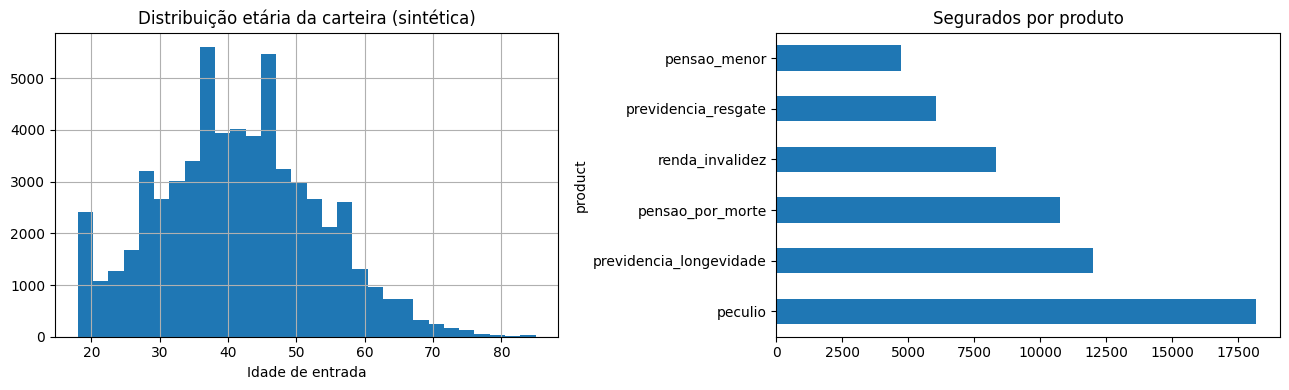

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
policyholders["entry_age"].hist(bins=30, ax=axes[0])
axes[0].set_title("Distribuição etária da carteira (sintética)")
axes[0].set_xlabel("Idade de entrada")

policyholders["product"].value_counts().plot(kind="barh", ax=axes[1])
axes[1].set_title("Segurados por produto")
plt.tight_layout()
plt.savefig("../reports/results/01_portfolio_overview.png", dpi=120)
plt.show()


## 2. Verificação de Consistência Interna (A/E Ratio)

Como os sinistros foram gerados por sorteio Bernoulli usando a própria tábua biométrica base,
o A/E ratio agregado deve ficar **próximo de 100%** (dentro do ruído amostral esperado) — essa é
a verificação de que o dataset sintético é internamente coerente antes de qualquer outra análise.

Reproduz a metodologia de conciliação em 3 categorias (oficial / sensibilidade / pendente)
documentada em `METODOLOGIA_MESTRE.md`, seção 3.2.

In [4]:
from src.actuarial.experience_engine import ae_ratio_by_cell, ae_ratio_summary, reconcile_claims
from src.validation.diagnostics import internal_consistency_check, chi_square_ae_test

peculio_exposure = exposure[exposure["product"] == "peculio"].copy()
peculio_claims = claims[claims["product"] == "peculio"].copy()

reconciled = reconcile_claims(peculio_claims, peculio_exposure)
print("Distribuição da conciliação (oficial / sensibilidade / pendente):")
print(reconciled["reconciliation_status"].value_counts())
print()

cell_df = ae_ratio_by_cell(peculio_exposure, peculio_claims, age_band_width=5, include_status=("oficial", "sensibilidade"))
total_observed = cell_df["observed_events"].sum()
total_expected = cell_df["expected_events"].sum()

print(f"Eventos observados: {total_observed:,.0f}")
print(f"Eventos esperados (tábua): {total_expected:,.1f}")
print(f"A/E Ratio (Peculio): {total_observed/total_expected:.2%}")


Distribuição da conciliação (oficial / sensibilidade / pendente):
reconciliation_status
oficial    2863
Name: count, dtype: int64



Eventos observados: 2,863
Eventos esperados (tábua): 2,889.9
A/E Ratio (Peculio): 99.07%


In [5]:
consistency = internal_consistency_check(total_observed, total_expected, tolerance=0.30)
print(consistency["interpretation"])
assert consistency["within_tolerance"], "Dataset sintético não passou na verificação de consistência interna!"

chi2 = chi_square_ae_test(total_observed, total_expected, n_cells=cell_df["age_band"].nunique())
print(f"\nQui-quadrado: estatística={chi2['chi2_statistic']:.2f}, p-valor={chi2['p_value']:.4f}")
print(chi2["interpretation"])


A/E = 99.1% está dentro da tolerância de +/-30% do esperado (100%) — dataset sintético consistente com a tábua geradora.

Qui-quadrado: estatística=0.25, p-valor=1.0000
Sem evidência de diferença significativa entre observado e esperado.


In [6]:
ae_by_product = ae_ratio_summary(
    pd.concat([
        ae_ratio_by_cell(exposure[exposure["product"] == p].copy(), claims[claims["product"] == p].copy(), include_status=("oficial","sensibilidade")).assign(product=p)
        for p in policyholders["product"].unique()
    ]),
    group_cols=["product"],
)
ae_by_product.sort_values("ae_ratio", ascending=False)


,product,observed_events,expected_events,ae_ratio
5,renda_invalidez,"1,482.0000","1,244.9806",1.1904
2,pensao_por_morte,"1,657.0000","1,667.5865",0.9937
0,peculio,"2,863.0000","2,889.8601",0.9907
1,pensao_menor,721.0000,736.9298,0.9784
3,previdencia_longevidade,"1,544.0000","1,953.4641",0.7904
4,previdencia_resgate,714.0000,"1,036.6097",0.6888


## 3. Série Histórica de Sinistralidade Mensal (Peculio)

`sinistralidade = sinistro pago / contribuição arrecadada`, por mês — a métrica usada como
insumo direto da simulação de Monte Carlo (seção 5).

Série com 96 meses
Sinistralidade média: 24.31%
Sinistralidade mediana: 23.50%


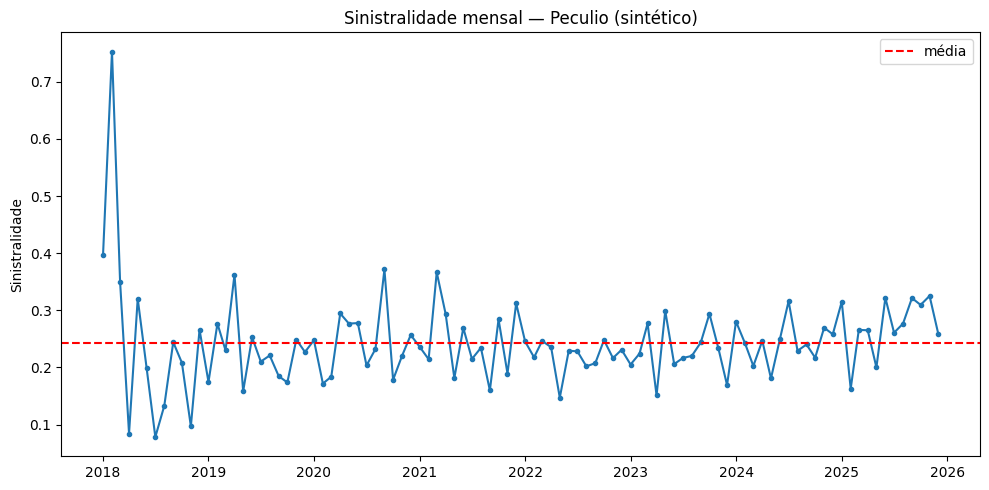

In [7]:
from src.actuarial.experience_engine import monthly_loss_ratio_series

mlr = monthly_loss_ratio_series(peculio_exposure, peculio_claims)
print(f"Série com {len(mlr)} meses")
print(f"Sinistralidade média: {mlr['loss_ratio'].mean():.2%}")
print(f"Sinistralidade mediana: {mlr['loss_ratio'].median():.2%}")

fig, ax = plt.subplots()
ax.plot(mlr["year_month"], mlr["loss_ratio"], marker="o", markersize=3)
ax.axhline(mlr["loss_ratio"].mean(), color="red", linestyle="--", label="média")
ax.set_title("Sinistralidade mensal — Peculio (sintético)")
ax.set_ylabel("Sinistralidade")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/results/02_loss_ratio_series.png", dpi=120)
plt.show()


### 3.1 Diagnóstico Temporal (Autocorrelação)

Verifica se a sinistralidade é dirigida por oscilação aleatória (sem tendência/dependência forte entre meses) — replica o diagnóstico feito no projeto original.

In [8]:
from src.validation.diagnostics import autocorrelation_check

ac = autocorrelation_check(mlr["loss_ratio"].values, lags=(1, 12))
print(ac)
print("\nInterpretação: autocorrelação baixa em ambos os lags sugere que a sinistralidade")
print("não tem tendência de tempo nem sazonalidade forte — consistente com um processo estacionário.")


   lag  autocorrelation
0    1           0.1657
1   12          -0.0635

Interpretação: autocorrelação baixa em ambos os lags sugere que a sinistralidade
não tem tendência de tempo nem sazonalidade forte — consistente com um processo estacionário.


## 4. Seleção de Distribuição Estatística

Compara Gamma, Lognormal e Normal por AIC/BIC/teste de aderência (Kolmogorov-Smirnov),
com a razoabilidade teórica do suporte de cada uma — não apenas o critério numérico
(metodologia, seção 3.4).

In [9]:
from src.modeling.distribution_fit import select_best_distribution

best_dist, comparison = select_best_distribution(mlr["loss_ratio"].values, candidates=["gamma", "lognorm", "norm"])
print(f"Distribuição selecionada: {best_dist.distribution.upper()} (AIC={best_dist.aic:.2f}, KS p-valor={best_dist.ks_pvalue:.3f})")
comparison


Distribuição selecionada: LOGNORM (AIC=-233.29, KS p-valor=0.401)


,distribution,aic,bic,ks_statistic,ks_pvalue,support_note
0,lognorm,-233.2921,-225.5991,0.0896,0.4007,"suporte em (0, +inf) — assimetria positiva, ma..."
1,gamma,-230.2043,-222.5113,0.0909,0.3832,"suporte em [0, +inf) — compatível com sinistra..."
2,norm,-210.9808,-205.8521,0.1222,0.1043,"suporte em (-inf, +inf) — permite valores nega..."


In [10]:
from src.modeling.frequency_severity import fit_frequency, fit_severity_lognormal

monthly_counts = peculio_claims.groupby("occurrence_month").size()
# reindexa para incluir meses com zero sinistros
all_months = pd.date_range(mlr["year_month"].min(), mlr["year_month"].max(), freq="MS")
monthly_counts = monthly_counts.reindex(all_months, fill_value=0)

freq_result, freq_comparison = fit_frequency(monthly_counts.values)
print(f"Frequência — distribuição selecionada: {freq_result.distribution.upper()}")
print(f"  Média={freq_result.mean:.2f} eventos/mês | Variância={freq_result.variance:.2f} | razão var/média={freq_result.dispersion_ratio:.2f}")
print(freq_comparison)

sev_result = fit_severity_lognormal(peculio_claims["benefit_reference"].values)
print(f"\nSeveridade (Lognormal) — média empírica=R$ {sev_result['empirical_mean']:,.0f} | mediana empírica=R$ {sev_result['empirical_median']:,.0f}")


Frequência — distribuição selecionada: NBINOM
  Média=29.82 eventos/mês | Variância=327.07 | razão var/média=10.97
  distribution        aic                                     params
0       nbinom   835.3189  (2.9921089655650266, 0.09118106440319541)
1      poisson 1,639.3785                      (29.822916666666668,)

Severidade (Lognormal) — média empírica=R$ 341,541 | mediana empírica=R$ 340,552


## 5. Simulação de Monte Carlo — Calibração do Fator de Stress

Reproduz a mecânica exata documentada na metodologia (seção 3.5): cada cenário sorteia uma
série de N meses (zero com probabilidade `p0` estimada empiricamente, ou amostrada da
distribuição ajustada), calcula a média, e repete por milhares de cenários — gerando a
distribuição empírica de onde se extrai o percentil-alvo.

In [11]:
from src.simulation.monte_carlo import run_monte_carlo, estimate_zero_probability

p0 = estimate_zero_probability(mlr["loss_ratio"].values)
print(f"P0 (probabilidade de mês com sinistralidade zero, estimada empiricamente): {p0:.2%}")

mc_conf = CONFIG["monte_carlo"]
rar_conf = CONFIG["risk_adjustment"]

mc_result = run_monte_carlo(
    mlr["loss_ratio"].values,
    distribution=best_dist.distribution,
    n_scenarios=mc_conf["n_scenarios"],
    seed=CONFIG["seed"],
    zero_probability=p0,
    target_percentiles=tuple(rar_conf["target_percentiles"]),
)

print(f"\nMediana simulada (P50): {mc_result.median_simulated:.4f}")
for p in rar_conf["target_percentiles"]:
    print(f"P{p}: {mc_result.percentiles[p]:.4f}  |  Fator de stress: {mc_result.stress_factor(p):.4f}  |  AR (p.p.): {mc_result.ar_points(p)*100:.2f}  |  CTE: {mc_result.cte(p):.4f}")


P0 (probabilidade de mês com sinistralidade zero, estimada empiricamente): 0.00%

Mediana simulada (P50): 0.2432
P75: 0.2485  |  Fator de stress: 1.0219  |  AR (p.p.): 0.53  |  CTE: 0.2533
P80: 0.2498  |  Fator de stress: 1.0272  |  AR (p.p.): 0.66  |  CTE: 0.2544
P90: 0.2534  |  Fator de stress: 1.0420  |  AR (p.p.): 1.02  |  CTE: 0.2573


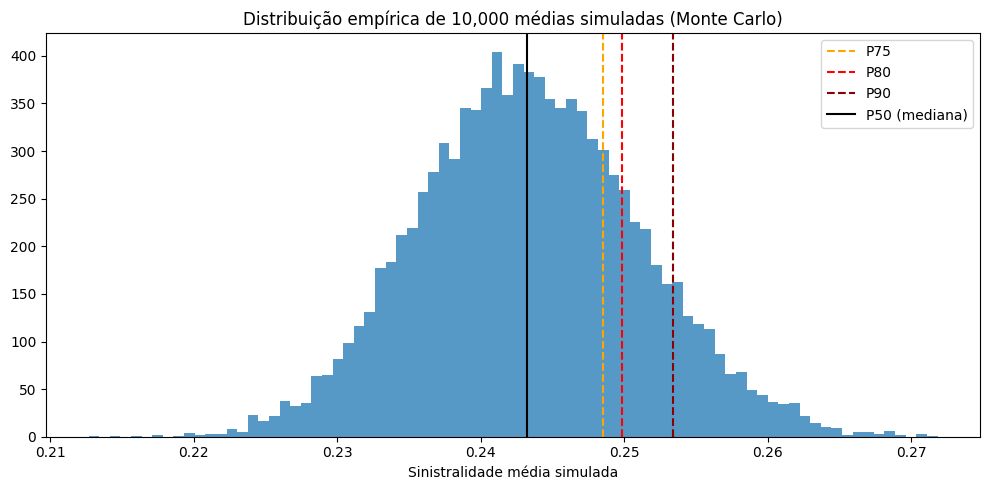

In [12]:
fig, ax = plt.subplots()
ax.hist(mc_result.simulated_means, bins=80, alpha=0.75)
for p, color in zip(rar_conf["target_percentiles"], ["orange", "red", "darkred"]):
    ax.axvline(mc_result.percentiles[p], color=color, linestyle="--", label=f"P{p}")
ax.axvline(mc_result.median_simulated, color="black", linestyle="-", label="P50 (mediana)")
ax.set_title(f"Distribuição empírica de {mc_conf['n_scenarios']:,} médias simuladas (Monte Carlo)")
ax.set_xlabel("Sinistralidade média simulada")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/results/03_monte_carlo_distribution.png", dpi=120)
plt.show()


### 5.1 Teste de Convergência

Verifica que o fator de stress estabiliza conforme o número de cenários aumenta, justificando tecnicamente a escolha da quantidade de simulações (proposta de melhoria não implementada no projeto original — metodologia, seção 8, item 5).

In [13]:
from src.simulation.monte_carlo import convergence_test

records, converged = convergence_test(
    mlr["loss_ratio"].values,
    distribution=best_dist.distribution,
    scenario_sizes=mc_conf["convergence_check_sizes"],
    target_percentile=rar_conf["default_percentile"],
    seed=CONFIG["seed"],
    tolerance=mc_conf["convergence_tolerance"],
)
conv_df = pd.DataFrame(records)
print(conv_df)
print(f"\nConvergiu (variação < {mc_conf['convergence_tolerance']:.0%} entre os dois maiores tamanhos testados)? {converged}")


   n_scenarios  stress_factor
0         1000         1.0284
1         5000         1.0266
2        10000         1.0272
3        50000         1.0272

Convergiu (variação < 1% entre os dois maiores tamanhos testados)? True


### 5.2 Validação contra Benchmark Solvency II

Posiciona o fator de stress obtido contra o choque padrão de mortalidade do Solvency II
europeu (EIOPA, 99,5% de confiança a 1 ano) — a mesma lógica de defesa usada no projeto real
(metodologia, seção 2 Fase 6): um percentil menor que 99,5% deve produzir, por construção,
um stress proporcionalmente menor que o benchmark.

In [14]:
from src.risk_adjustment.ar_engine import solvency_ii_benchmark_check

default_p = rar_conf["default_percentile"]
stress_factor = mc_result.stress_factor(default_p)

sii_check = solvency_ii_benchmark_check(
    stress_factor=stress_factor,
    target_percentile=default_p,
    sii_shock=CONFIG["solvency_ii_benchmark"]["mortality_shock"],
)
for k, v in sii_check.items():
    print(f"{k}: {v}")


our_stress_pct: 0.02715077136655375
our_confidence_level: 0.8
solvency_ii_shock_pct: 0.15
solvency_ii_confidence_level: 0.995
directionally_consistent: True
interpretation: Consistente: percentil de confiança menor que o Solvency II (99,5%) produziu, como esperado, um stress proporcionalmente menor que o benchmark europeu.


## 6. Credibility Testing (Bühlmann)

Item identificado na metodologia original mas nunca implementado em código (gap #8) —
implementado aqui: células com pouca exposição têm o A/E ajustado em direção ao benchmark
de mercado (A/E = 1.0), proporcional ao volume de dados disponível.

In [15]:
from src.actuarial.credibility import apply_credibility

cred_df = apply_credibility(
    cell_df,
    full_credibility_exposure=CONFIG["experience_engine"]["min_exposure_credibility"],
    full_credibility_events=CONFIG["experience_engine"]["min_events_credibility"],
)
print(f"Células analisadas: {len(cred_df)}")
print(f"Fator de credibilidade médio (Z): {cred_df['credibility_z'].mean():.2f}")
print(f"% de células com credibilidade plena (Z=1.0): {(cred_df['credibility_z'] >= 0.999).mean():.1%}")

cred_df[["age_band", "sex", "n_exposed", "observed_events", "ae_ratio_raw", "credibility_z", "ae_ratio_credibility_adjusted"]].sort_values("n_exposed", ascending=False).head(10)


Células analisadas: 2694
Fator de credibilidade médio (Z): 0.12
% de células com credibilidade plena (Z=1.0): 0.0%


,age_band,sex,n_exposed,observed_events,ae_ratio_raw,credibility_z,ae_ratio_credibility_adjusted
1049,40,female,1430,2.0000,0.8023,0.2582,0.9490
1048,40,female,1429,2.0000,0.8031,0.2582,0.9492
1047,40,female,1422,2.0000,0.8067,0.2582,0.9501
1046,40,female,1414,2.0000,0.8114,0.2582,0.9513
1050,40,female,1413,5.0000,2.0302,0.4082,1.4206
1045,40,female,1408,1.0000,0.4077,0.1826,0.8919
1051,40,female,1407,1.0000,0.4079,0.1826,0.8919
1052,40,female,1403,2.0000,0.8185,0.2582,0.9531
1053,40,female,1400,2.0000,0.8194,0.2582,0.9534
1054,40,female,1396,0.0000,0.0000,0.0000,1.0000


## 7. Cálculo do BEL e do AR por Componente ("Caixinhas")

Aplica o fator de stress calibrado (seção 5) sobre a tábua biométrica de cada produto e
recalcula o BEL — `AR = BEL_stress - BEL_base` — para cada "caixinha" de risco
(metodologia, seções 3.6-3.9).

In [16]:
from src.risk_adjustment.ar_engine import compute_component_ar, STRESS_DIRECTION

discount_rate = CONFIG["mortality"]["discount_rate_annual"]
components_to_compute = ["peculio", "pensao_por_morte", "renda_invalidez", "pensao_menor", "previdencia_longevidade"]

component_results = {}
for product in components_to_compute:
    result = compute_component_ar(product, policyholders, stress_factor, default_p, discount_rate)
    component_results[product] = result
    direction_label = "mortalidade (stress para cima)" if STRESS_DIRECTION[product] > 0 else "longevidade (stress para baixo no QX)"
    print(f"{product:28s} | direção: {direction_label:35s} | BEL_base=R$ {result.bel_base:>15,.0f} | AR=R$ {result.ar_monetary:>13,.0f} ({result.ar_pct_of_bel:.2%})")


peculio                      | direção: mortalidade (stress para cima)      | BEL_base=R$   2,826,323,926 | AR=R$    29,715,004 (1.05%)
pensao_por_morte             | direção: mortalidade (stress para cima)      | BEL_base=R$   4,213,515,841 | AR=R$    44,464,606 (1.06%)


renda_invalidez              | direção: mortalidade (stress para cima)      | BEL_base=R$   3,804,735,429 | AR=R$    33,867,873 (0.89%)
pensao_menor                 | direção: mortalidade (stress para cima)      | BEL_base=R$     395,526,369 | AR=R$     4,177,246 (1.06%)
previdencia_longevidade      | direção: longevidade (stress para baixo no QX) | BEL_base=R$   8,864,300,449 | AR=R$    76,538,737 (0.86%)


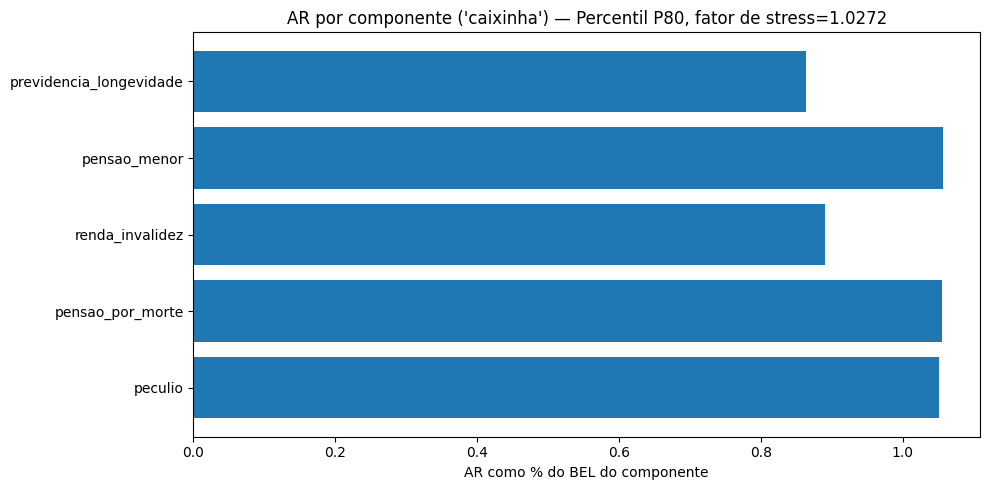

,produto,bel_base,bel_stress,ar_monetario,ar_pct_bel
0,peculio,"2,826,323,926.4546","2,856,038,930.4037","29,715,003.9491",0.0105
1,pensao_por_morte,"4,213,515,841.0037","4,257,980,447.4144","44,464,606.4107",0.0106
2,renda_invalidez,"3,804,735,429.0000","3,838,603,302.0442","33,867,873.0442",0.0089
3,pensao_menor,"395,526,369.1111","399,703,615.1766","4,177,246.0654",0.0106
4,previdencia_longevidade,"8,864,300,448.7358","8,940,839,185.4772","76,538,736.7414",0.0086


In [17]:
results_df = pd.DataFrame([
    {"produto": p, "bel_base": r.bel_base, "bel_stress": r.bel_stress, "ar_monetario": r.ar_monetary, "ar_pct_bel": r.ar_pct_of_bel}
    for p, r in component_results.items()
])

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(results_df["produto"], results_df["ar_pct_bel"] * 100)
ax.set_xlabel("AR como % do BEL do componente")
ax.set_title(f"AR por componente ('caixinha') — Percentil P{default_p}, fator de stress={stress_factor:.4f}")
plt.tight_layout()
plt.savefig("../reports/results/04_ar_by_component.png", dpi=120)
plt.show()

results_df


## 8. Combinação das Caixinhas com Benefício de Diversificação

Soma simples dos componentes menos o benefício de diversificação (metodologia, seção 3.8)
— melhoria não implementada no projeto original (gap #4).

In [18]:
from src.risk_adjustment.ar_engine import combine_components

combined = combine_components(list(component_results.values()), diversification_benefit=rar_conf["diversification_benefit"])

print(f"BEL total (componentes calculados): R$ {combined['total_bel_base']:,.0f}")
print(f"AR — soma simples das caixinhas:     R$ {combined['ar_sum_simple']:,.0f}")
print(f"Benefício de diversificação:          {combined['diversification_benefit_pct']:.0%}")
print(f"AR — total diversificado:             R$ {combined['ar_diversified']:,.0f}  ({combined['ar_diversified_pct_of_bel']:.2%} do BEL)")
print(f"\nImpacto no CSM (queda de margem futura): R$ {combined['csm_reduction']:,.0f}")
print("Lembrete metodológico: cada R$1 de AR reduz o CSM em R$1 (METODOLOGIA_MESTRE.md, seção 1.1)")


BEL total (componentes calculados): R$ 20,104,402,014
AR — soma simples das caixinhas:     R$ 188,763,466
Benefício de diversificação:          15%
AR — total diversificado:             R$ 160,448,946  (0.80% do BEL)

Impacto no CSM (queda de margem futura): R$ 160,448,946
Lembrete metodológico: cada R$1 de AR reduz o CSM em R$1 (METODOLOGIA_MESTRE.md, seção 1.1)


## 9. Cenário de Correlação Adversa (Longevidade + Conversão + Resgate)

O pior cenário para o AR de um produto de renda vitalícia não é estressar cada premissa
isoladamente — é a combinação correlacionada de mortalidade caindo, conversão subindo e
resgate caindo simultaneamente (metodologia, seção 3.7). Nunca implementado no projeto
original (gap #7); aqui simulado via cópula Gaussiana — a mesma técnica usada no projeto
irmão `v2` (credit-risk-ecl-engine) para correlacionar segmentos de risco de crédito.

longevity_shift_p50: 0.9978
longevity_shift_pXX: 1.0660
conversion_shift_p50: 0.9974
conversion_shift_pXX: 1.0838
lapse_shift_p50: 1.0005
lapse_shift_pXX: 1.1246


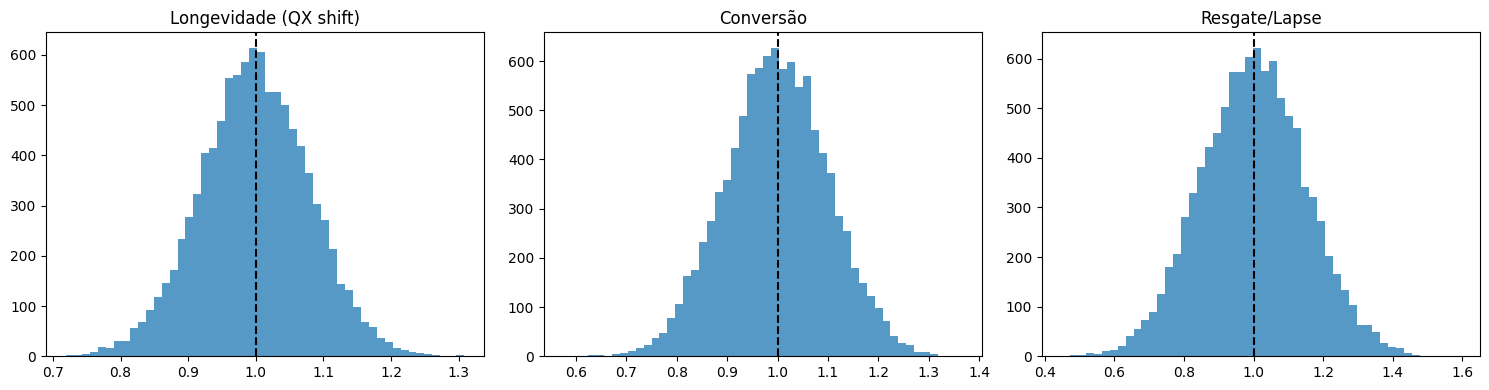


Interpretação: no percentil P80 do cenário conjunto, a longevidade cai (QX menor que 1.0),
a conversão sobe e o resgate cai simultaneamente — a combinação que maximiza a exposição
ao risco de longevidade total, consistente com a lógica qualitativa documentada na metodologia.


In [19]:
from src.risk_adjustment.correlation import simulate_adverse_correlation_scenario

adverse = simulate_adverse_correlation_scenario(
    n_scenarios=mc_conf["n_scenarios"],
    corr_longevity_conversion=rar_conf["adverse_correlation"]["longevity_conversion"],
    corr_longevity_lapse=rar_conf["adverse_correlation"]["longevity_lapse"],
    target_percentile=default_p,
    seed=CONFIG["seed"],
)
summary = adverse.summary()
for k, v in summary.items():
    print(f"{k}: {v:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (arr, name) in zip(axes, [(adverse.longevity_shift, "Longevidade (QX shift)"), (adverse.conversion_shift, "Conversão"), (adverse.lapse_shift, "Resgate/Lapse")]):
    ax.hist(arr, bins=50, alpha=0.75)
    ax.set_title(name)
    ax.axvline(1.0, color="black", linestyle="--")
plt.tight_layout()
plt.savefig("../reports/results/05_adverse_correlation_scenario.png", dpi=120)
plt.show()

print("\nInterpretação: no percentil P80 do cenário conjunto, a longevidade cai (QX menor que 1.0),")
print("a conversão sobe e o resgate cai simultaneamente — a combinação que maximiza a exposição")
print("ao risco de longevidade total, consistente com a lógica qualitativa documentada na metodologia.")


## 10. Sensibilidade ao Percentil-Alvo (P75 / P80 / P90)

Explora como o AR total muda conforme o percentil de confiança escolhido — insumo direto
para a decisão de negócio sobre qual nível reportar (nunca formalmente aprovado no projeto
original — gap #2).

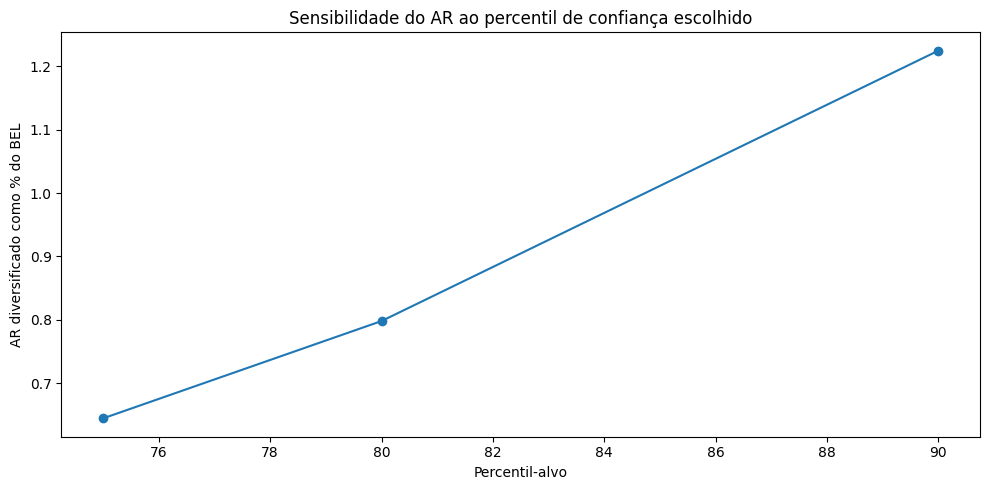

,percentil,fator_stress,ar_diversificado,ar_pct_bel
0,75,1.0219,"129,575,060.7676",0.0064
1,80,1.0272,"160,448,946.2792",0.0080
2,90,1.0420,"246,240,476.0668",0.0122


In [20]:
sensitivity_rows = []
for p in [75, 80, 90]:
    sf = mc_result.stress_factor(p)
    comps = [compute_component_ar(prod, policyholders, sf, p, discount_rate) for prod in components_to_compute]
    comb = combine_components(comps, diversification_benefit=rar_conf["diversification_benefit"])
    sensitivity_rows.append({
        "percentil": p,
        "fator_stress": sf,
        "ar_diversificado": comb["ar_diversified"],
        "ar_pct_bel": comb["ar_diversified_pct_of_bel"],
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
fig, ax = plt.subplots()
ax.plot(sensitivity_df["percentil"], sensitivity_df["ar_pct_bel"] * 100, marker="o")
ax.set_xlabel("Percentil-alvo")
ax.set_ylabel("AR diversificado como % do BEL")
ax.set_title("Sensibilidade do AR ao percentil de confiança escolhido")
plt.tight_layout()
plt.savefig("../reports/results/06_percentile_sensitivity.png", dpi=120)
plt.show()

sensitivity_df


## 11. Registro de Premissas (Audit Trail)

Formato hipótese / justificativa / limitação / fonte — o requisito de governança central
identificado como lição de processo do projeto original (metodologia, seção 2 Fase 5).

In [21]:
from src.governance.audit_trail import default_registry

registry = default_registry(CONFIG)
assumptions_df = registry.to_dataframe()
assumptions_df.to_csv("../reports/results/assumptions_registry.csv", index=False)

with open("../reports/assumptions.md", "w", encoding="utf-8") as f:
    f.write("# Registro de Premissas — pension-risk-adjustment-engine\n\n")
    f.write(registry.to_markdown())

assumptions_df


,name,value,justification,limitation,source
0,Tábuas de mortalidade,"Aproximação paramétrica (Makeham), não a tábua...",Tábuas oficiais têm distribuição restrita (IBA...,Valores de qx não correspondem exatamente aos ...,src/data/mortality_tables.py; Makeham (1860); ...
1,Portfólio,"100% sintético, gerado por simulação",Nenhum dado real de nenhuma carteira/instituiç...,"Distribuição etária, de produtos e de capital ...",src/data/synthetic_portfolio.py
2,Probabilidade de mês com sinistralidade zero (p0),Estimada empiricamente da série sintética gera...,O projeto original fixou p0 por decisão do ana...,Ainda assume que a taxa histórica de meses com...,src/simulation/monte_carlo.py::estimate_zero_p...
3,Percentil-alvo do AR,80,Dentro da faixa de mercado internacional (75%-...,O projeto original nunca obteve aprovação form...,Moodys — Equivalent Confidence Level for the I...
4,Benefício de diversificação entre componentes,15% de redução sobre a soma simples das caixinhas,Recomendação de organismos atuariais (CIA) par...,Percentual ilustrativo — calibração real exigi...,CIA — Educational Note: IFRS 17 RA for Life an...
5,Semente do gerador aleatório (seed),42,Fixada explicitamente em todas as simulações p...,"Nenhuma — requisito de governança, não uma lim...","METODOLOGIA_MESTRE.md, Fase 5, item 5 (lição d..."


## 12. Exportação dos Resultados Finais

Consolida todos os resultados numéricos gerados neste notebook em um único artefato,
para consumo pelo dashboard (`dashboard/app.py`) e para o relatório final.

In [22]:
import json

final_results = {
    "config": CONFIG,
    "dataset_summary": {
        "n_policyholders": len(policyholders),
        "n_exposure_rows": len(exposure),
        "n_claims": len(claims),
    },
    "ae_ratio_peculio": float(total_observed / total_expected),
    "chi_square_test": chi2,
    "distribution_selected": best_dist.distribution,
    "distribution_comparison": comparison.to_dict(orient="records"),
    "monte_carlo": {
        "p0": float(p0),
        "median_simulated": mc_result.median_simulated,
        "percentiles": mc_result.percentiles,
        "stress_factors": {str(p): mc_result.stress_factor(p) for p in rar_conf["target_percentiles"]},
        "convergence_records": records,
        "converged": converged,
    },
    "solvency_ii_benchmark": sii_check,
    "components": {p: {"bel_base": r.bel_base, "bel_stress": r.bel_stress, "ar_monetary": r.ar_monetary, "ar_pct_of_bel": r.ar_pct_of_bel} for p, r in component_results.items()},
    "combined": combined,
    "adverse_correlation_scenario": summary,
    "percentile_sensitivity": sensitivity_df.to_dict(orient="records"),
}

with open("../reports/results/final_results.json", "w", encoding="utf-8") as f:
    json.dump(final_results, f, indent=2, default=str, ensure_ascii=False)

print("Resultados exportados para reports/results/final_results.json")
print(f"\n{'='*70}")
print("RESUMO EXECUTIVO")
print(f"{'='*70}")
print(f"A/E Ratio (Peculio, dataset sintético): {final_results['ae_ratio_peculio']:.1%}")
print(f"Distribuição selecionada: {best_dist.distribution.upper()}")
print(f"Fator de stress (P{default_p}): {stress_factor:.4f}")
print(f"AR diversificado total: R$ {combined['ar_diversified']:,.0f} ({combined['ar_diversified_pct_of_bel']:.2%} do BEL)")
print(f"Consistente com benchmark Solvency II: {sii_check['directionally_consistent']}")


Resultados exportados para reports/results/final_results.json

RESUMO EXECUTIVO
A/E Ratio (Peculio, dataset sintético): 99.1%
Distribuição selecionada: LOGNORM
Fator de stress (P80): 1.0272
AR diversificado total: R$ 160,448,946 (0.80% do BEL)
Consistente com benchmark Solvency II: True


## 13. Conclusões e Próximos Passos

Este notebook implementa de ponta a ponta a metodologia consolidada em
`itau/METODOLOGIA_MESTRE.md`, endereçando as melhorias identificadas na seção 8 daquele
documento que não puderam ser concluídas no projeto original:

- ✅ Credibility Testing de Bühlmann implementado (era apenas formulado).
- ✅ Benefício de diversificação entre componentes implementado (era soma simples).
- ✅ Cenário de correlação adversa simulado conjuntamente via cópula Gaussiana (era apenas qualitativo).
- ✅ CTE calculado como validação cruzada de cada percentil (não apenas o VaR/percentil isolado).
- ✅ Teste de convergência do número de cenários formalizado e documentado.
- ✅ Componentes de Longevidade, Invalidez e Pensão ao Menor implementados de ponta a ponta (no projeto original, só o Peculio avançou com dados).
- ⏳ Modelo de resgate/lapse via ordenação convexa (referência MDPI 2023) — ainda não implementado; próxima extensão natural do projeto.
- ⏳ Dashboard interativo (`dashboard/app.py`) — ver projeto separado no repositório.

**Todos os resultados numéricos acima são gerados por um dataset 100% sintético e não
representam, em nenhuma medida, dados ou resultados de nenhuma carteira real.**
